In [26]:
# ================= Gráfico simple: n por grupo vs efecto =================
suppressPackageStartupMessages({ library(ggplot2) })

# Potencia t de dos colas con t no central
power_t_twosided <- function(delta, df, alpha = 0.05){
  tcrit <- qt(1 - alpha/2, df)
  pt(-tcrit, df, ncp = delta) + (1 - pt(tcrit, df, ncp = delta))
}

# Contraste L1 en "ítems": (T1+T2)/2 vs Control
# d_avg = (Δ_avg_items / SD);  ncp δ = d_avg * sqrt(n/1.5)
power_L1_items <- function(n, delta_avg_items, sd, alpha = 0.05){
  df <- 3*n - 3
  d_avg <- delta_avg_items / sd
  delta <- d_avg * sqrt(n/1.5)
  power_t_twosided(delta, df, alpha)
}

# Contraste L2 en "ítems": T2 vs T1
# d_diff = (Δ_diff_items / SD); ncp δ = d_diff * sqrt(n/2)
power_L2_items <- function(n, delta_diff_items, sd, alpha = 0.05){
  df <- 3*n - 3
  d_diff <- delta_diff_items / sd
  delta <- d_diff * sqrt(n/2)
  power_t_twosided(delta, df, alpha)
}

# Busca n mínimo por grupo para alcanzar el poder objetivo (búsqueda discreta rápida)
n_required_curve <- function(eff_seq, sd, which = c("L1","L2"),
                             alpha = 0.05, target_power = 0.80,
                             n_min = 5, n_max = 400){
  which <- match.arg(which)
  n_grid <- n_min:n_max
  sapply(eff_seq, function(eff){
    pv <- if (which == "L1") sapply(n_grid, function(n) power_L1_items(n, eff, sd, alpha))
          else               sapply(n_grid, function(n) power_L2_items(n, eff, sd, alpha))
    idx <- which(pv >= target_power)
    if (length(idx) == 0) NA_integer_ else n_grid[min(idx)]
  })
}

# ====================== CONFIGURACIÓN RÁPIDA ======================
alpha <- 0.05
target_power <- 0.80

# Curvas por SD (elige las que quieras mostrar)
sd_vals <- c(1.6, 2.0, 2.4)

# Ejes X = efectos en ítems
eff_L1_seq  <- seq(0.4, 2.0, by = 0.1)   # Δ_avg (L1)
eff_L2_seq  <- seq(0.3, 1.2, by = 0.05)  # Δ_diff (L2)

# Escenarios sobre SD=2 (marcas de referencia)
scen_L1 <- data.frame(sd = 2, eff = c(0.9, 1.15, 1.5), label = c("Cons", "Mod", "Amb"))
scen_L2 <- data.frame(sd = 2, eff = c(0.6, 0.7, 1.0),  label = c("Cons", "Mod", "Amb"))

# ====================== CÁLCULO DE CURVAS ======================
curves_L1 <- do.call(rbind, lapply(sd_vals, function(s){
  n_req <- n_required_curve(eff_L1_seq, sd = s, which = "L1",
                            alpha = alpha, target_power = target_power)
  data.frame(which = "L1", sd = factor(s), eff = eff_L1_seq, n = n_req)
}))

curves_L2 <- do.call(rbind, lapply(sd_vals, function(s){
  n_req <- n_required_curve(eff_L2_seq, sd = s, which = "L2",
                            alpha = alpha, target_power = target_power)
  data.frame(which = "L2", sd = factor(s), eff = eff_L2_seq, n = n_req)
}))

# ====================== GRÁFICOS SENCILLOS ======================
# L1: (T1+T2)/2 vs Control
p_L1 <- ggplot(curves_L1, aes(x = eff, y = n, color = sd)) +
  geom_line(linewidth = 1) +
  geom_point(data = subset(curves_L1, sd == "2"), size = 0.8) +
  geom_point(data = transform(scen_L1, n = NA), alpha = 0) +  # para fijar escala x
  labs(title = "n por grupo requerido (80% poder, α = 0.05)",
       subtitle = "Contraste L1: (T1+T2)/2 vs Control",
       x = expression(Delta["avg"]~"(ítems)"), y = "n por grupo", color = "SD") +
  theme_classic(base_size = 12)

# L2: T2 vs T1
p_L2 <- ggplot(curves_L2, aes(x = eff, y = n, color = sd)) +
  geom_line(linewidth = 1) +
  geom_point(data = subset(curves_L2, sd == "2"), size = 0.8) +
  labs(title = "n por grupo requerido (80% poder, α = 0.05)",
       subtitle = "Contraste L2: T2 vs T1",
       x = expression(Delta["diff"]==T2 - T1~"(ítems)"), y = "n por grupo", color = "SD") +
  theme_classic(base_size = 12)

print(p_L1)
print(p_L2)

# ================= Opcional: totales (por si los necesitas) =================
# total_personas = 12 * ceiling(n/4)
# Ejemplo: añadir columna total para curvas_L1
# curves_L1$total <- 12 * ceiling(curves_L1$n / 4)
# write.csv(curves_L1, "curvas_L1_n_y_total.csv", row.names = FALSE)
# write.csv(curves_L2, "curvas_L2_n_y_total.csv", row.names = FALSE)


ERROR: [1m[33mError[39m in `scale_y_continuous()`:[22m
[1m[22m[33m![39m Discrete values supplied to continuous scale.
[36mℹ[39m Example values: [34mNA[39m, [34mNA[39m, and [34mNA[39m


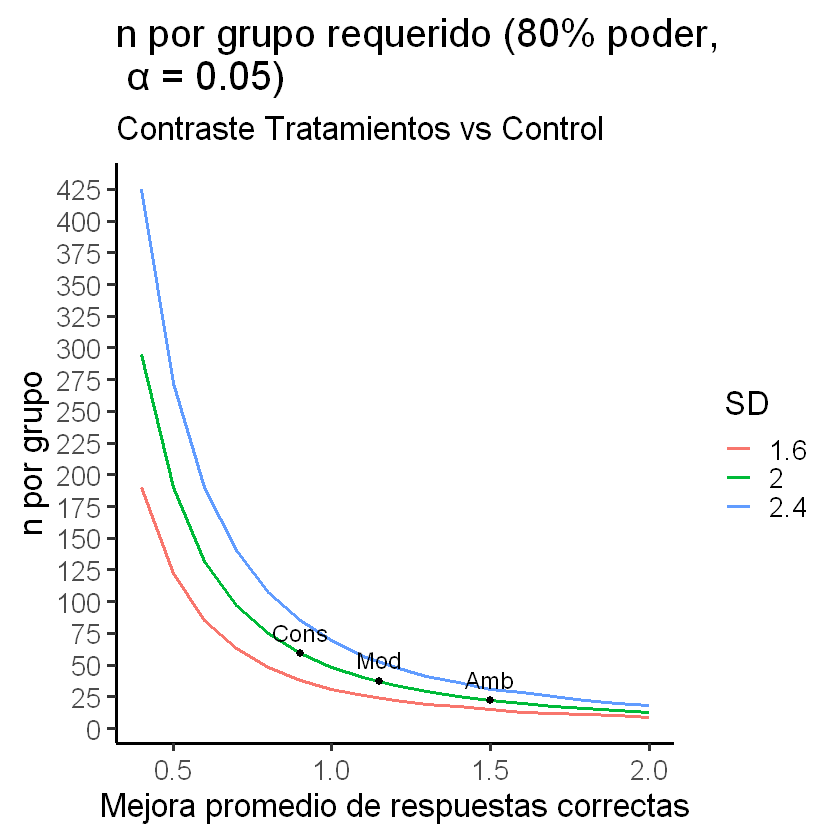

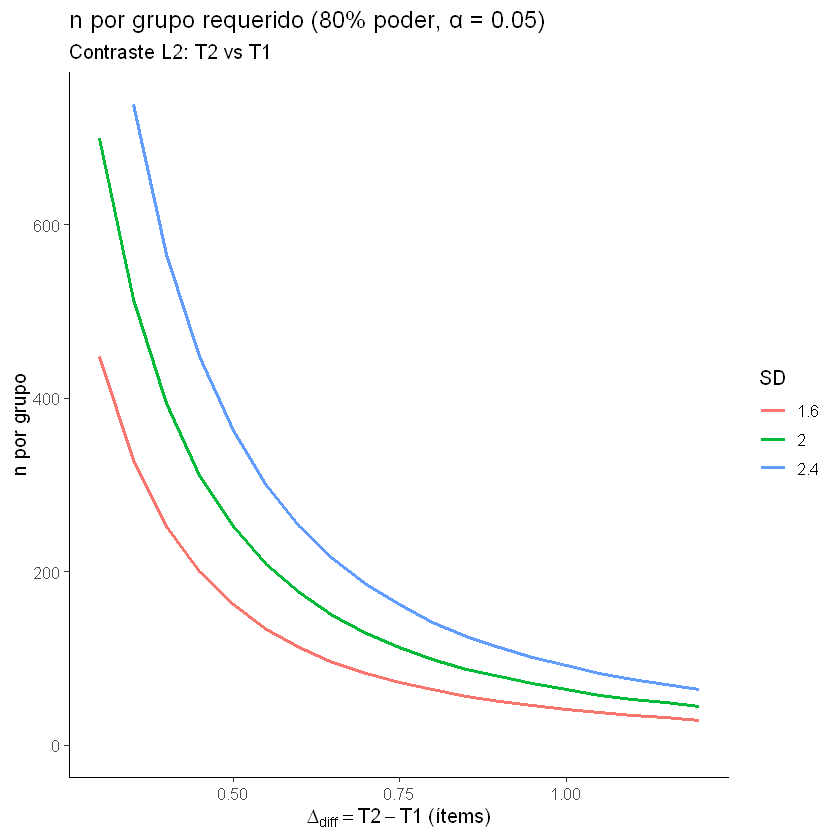

In [38]:
suppressPackageStartupMessages({ library(ggplot2) })

# --- Potencia t bilateral con ncp ---
power_t_twosided <- function(delta, df, alpha = 0.05){
  tcrit <- qt(1 - alpha/2, df)
  pt(-tcrit, df, ncp = delta) + (1 - pt(tcrit, df, ncp = delta))
}

# --- Contrastes en "ítems" ---
# L1: (T1+T2)/2 vs Control  -> d_avg = Δ_avg / SD; δ = d_avg * sqrt(n/1.5)
power_L1_items <- function(n, delta_avg_items, sd, alpha = 0.05){
  df <- 3*n - 3
  d_avg <- delta_avg_items / sd
  delta <- d_avg * sqrt(n/1.5)
  power_t_twosided(delta, df, alpha)
}
# L2: T2 vs T1               -> d_diff = Δ_diff / SD; δ = d_diff * sqrt(n/2)
power_L2_items <- function(n, delta_diff_items, sd, alpha = 0.05){
  df <- 3*n - 3
  d_diff <- delta_diff_items / sd
  delta <- d_diff * sqrt(n/2)
  power_t_twosided(delta, df, alpha)
}

# --- n mínimo (discreto) para un poder objetivo ---
n_required_curve <- function(eff_seq, sd, which = c("L1","L2"),
                             alpha = 0.05, target_power = 0.80,
                             n_min = 5, n_max = 800){   # sube n_max si hace falta
  which <- match.arg(which)
  n_grid <- n_min:n_max
  sapply(eff_seq, function(eff){
    pv <- if (which == "L1") sapply(n_grid, function(n) power_L1_items(n, eff, sd, alpha))
          else               sapply(n_grid, function(n) power_L2_items(n, eff, sd, alpha))
    idx <- which(pv >= target_power)
    if (length(idx) == 0) NA_integer_ else n_grid[min(idx)]
  })
}

# ========= CONFIG =========
alpha <- 0.05
target_power <- 0.80

sd_vals <- c(1.6, 2.0, 2.4)   # curvas a mostrar

eff_L1_seq <- seq(0.4, 2.0, by = 0.1)    # Δ_avg (ítems) para L1
eff_L2_seq <- seq(0.3, 1.2, by = 0.05)   # Δ_diff (ítems) para L2

# Escenarios propuestos (sobre SD=2)
scen_L1_eff <- c(0.9, 1.15, 1.5)  # Conservador, Moderado, Ambicioso
scen_L2_eff <- c(0.6, 0.7, 1.0)
scen_labels <- c("Cons", "Mod", "Amb")

# ========= CÁLCULO DE CURVAS =========
mk_curves <- function(sd_list, eff_seq, which){
  do.call(rbind, lapply(sd_list, function(s){
    n_req <- n_required_curve(eff_seq, sd = s, which = which,
                              alpha = alpha, target_power = target_power)
    data.frame(which = which, sd = factor(s), eff = eff_seq, n = as.numeric(n_req))
  }))
}

curves_L1 <- mk_curves(sd_vals, eff_L1_seq, "L1")
curves_L2 <- mk_curves(sd_vals, eff_L2_seq, "L2")

# Puntos reales para los escenarios (se calculan n, no NA)
scenario_points <- function(effs, sd_target, which){
  n_req <- n_required_curve(eff_seq = effs, sd = sd_target, which = which,
                            alpha = alpha, target_power = target_power)
  data.frame(sd = factor(sd_target), eff = effs, n = as.numeric(n_req))
}
scen_L1_pts <- scenario_points(scen_L1_eff, 2.0, "L1"); scen_L1_pts$label <- scen_labels
scen_L2_pts <- scenario_points(scen_L2_eff, 2.0, "L2"); scen_L2_pts$label <- scen_labels

# ========= GRÁFICOS (Y = n por grupo) =========
p_L1 <- ggplot(curves_L1, aes(x = eff, y = n, color = sd, group = sd)) +
  geom_line(linewidth = 1, na.rm = TRUE) +
  geom_point(data = scen_L1_pts, aes(x = eff, y = n), inherit.aes = FALSE, size = 2) +
  geom_text(data = scen_L1_pts, aes(x = eff, y = n, label = label),
            inherit.aes = FALSE, vjust = -0.7, size = 5) +
  scale_y_continuous(breaks = seq(0, 450, by = 25),        # etiquetas: 0, 25, 50, ...
    minor_breaks = seq(0, 450, by = 12.5) # líneas menores (sin etiqueta)
    ) +
  labs(title = "n por grupo requerido (80% poder, \n α = 0.05)",
       subtitle = "Contraste Tratamientos vs Control",
       x = "Mejora promedio de respuestas correctas" , y = "n por grupo", color = "SD") +
  theme_classic(base_size = 20)

p_L2 <- ggplot(curves_L2, aes(x = eff, y = n, color = sd, group = sd)) +
  geom_line(linewidth = 1, na.rm = TRUE) +
  #geom_point(data = scen_L2_pts, aes(x = eff, y = n), inherit.aes = FALSE, size = 2) +
  #geom_text(data = scen_L2_pts, aes(x = eff, y = n, label = label),
  #          inherit.aes = FALSE, vjust = -0.7, size = 3) +
  scale_y_continuous(limits = c(0, NA)) +
  labs(title = "n por grupo requerido (80% poder, α = 0.05)",
       subtitle = "Contraste L2: T2 vs T1",
       x = expression(Delta["diff"]==T2 - T1~"(ítems)"), y = "n por grupo", color = "SD") +
  theme_classic(base_size = 12)

print(p_L1)
print(p_L2)

